# Datasets and DataLoaders

For training, you can always use online datasets (pretty common) or you may want to create your own datasets for training and testing. In this notebook we will cover both, starting from the easiest case: working with online datasets. Good news is, torchvision, has built-in datasets and it also lets you build your own datasets.

For a list of all the built-in datasets: https://docs.pytorch.org/vision/main/datasets.html


**Available datasets**

the available datasets are defined as classes under torchvision.datasets. So for example, CIFAR10 dataset is a class and you can create an instance of it with datasets.CIFAR10. There's a reason why they haven't defined a single class for all the datasets! They could have define a Dataset class with a name attribute like cifar10. But they have different claasses for each dataset, meaning the attributes and methods for each dataset is so different that they had to package them in different classes. More specifically, torchvision has many different Dataset classes because each dataset has a different storage format, structure, and loading logic — but they all expose the same Dataset interface.

All datasets in torchvision.datasets are different implementations of the same abstract idea:
> Given an index i, return one (input, target) pair.

ALL OF THEM have  \_\_getitem__ and \_\_len__ methods meaning for all of them you can do len(dataset) to get the number of samples and dataset[i] to get the ith sample

In [8]:
# downloading a dataset:
## we can start with Caltech101
## ImageNet is more populat but it's massive and cannot be automatically downloaded 

import torchvision.datasets as datasets

my_caltech = datasets.Caltech101(root = "./data", 
                                target_type = 'category',  # can be annotation
                                transform = None, #  A function/transform that takes in a PIL image and returns a transformed version. E.g, transforms.RandomCrop
                                target_transform = None, # a function that transforms targets
                                download = True
                                )
my_caltech

Dataset Caltech101
    Number of datapoints: 8677
    Root location: ./data/caltech101
    Target type: ['category']

In [29]:
# now let's see what are the attributes and methods for my_caltech
print(dir(my_caltech))

['__add__', '__annotations__', '__class__', '__class_getitem__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__len__', '__lt__', '__module__', '__ne__', '__new__', '__orig_bases__', '__parameters__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slots__', '__str__', '__subclasshook__', '__weakref__', '_check_integrity', '_format_transform_repr', '_is_protocol', '_repr_indent', 'annotation_categories', 'categories', 'download', 'extra_repr', 'index', 'root', 'target_transform', 'target_type', 'transform', 'transforms', 'y']


In [33]:
# my_caltech.categories
# my_caltech.annotation_categories
# my_caltech.y

8677
(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=250x300 at 0x11C910690>, 41)


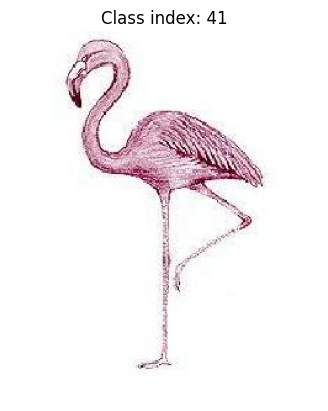

In [ ]:
# now let's take a look at this dataset
import matplotlib.pyplot as plt

# play around with different sample_idx
sample_idx = 5000
print(len(my_caltech))
print(my_caltech[sample_idx])
# wo
image, label = my_caltech[sample_idx]

plt.imshow(image)
plt.axis("off")
plt.title(f"Class index: {label}")
plt.show()

In [28]:
# now let's see how many unique labels there are in this dataset
import numpy as np

labels = [sample[1] for _, sample in enumerate(my_caltech)]
# get the unique labels (as implied in the name, there are 101 categories/labels)
np.unique(labels) 

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100])

## PIL (Python Image Library)

PIL appears a lot through out vision python pipelines. Type of images after you load a dataset is PIL.something (see above: PIL.JpegImagePlugin.JpegImageFile). So the images downloaded are not directly converted to numpy or toch tensors. 

A PIL Image is:
- A Python object That represents an image loaded from disk With
    - pixel values
    - size (width, height)
    - color mode (RGB, grayscale, etc.)

It is not. a tensor, a numpy arraay or something Pytorch can directly train on It's simply an image as a picture, not as math yet. The downloaded datasets use PIL objects because:
- It is lightweight
- Supports resizing, cropping, flipping
- Plays nicely with visualization (imshow)
- Is framework-agnostic

We later convert these PIL objects to either numpy array or tensors. Tensors because Pytorch works with them and it's also GPU friendly. So usually we either do: PIL → NumPy → Tensor OR PIL → Tensor. 

IMPORTANTLY, image processors (from torchvision of Hugging face) work with PIL images and apply the transformation on them. For example, the processor defined using Hugging face AutoImageProcessor accepts PIL object and breaks if you pass on tensors. And it returns tensors:

> inputs = processor(images=images, return_tensors="pt")


## DataLoaders

It represents a Python iterable over a dataset. It makes it easier to train/iterate over train and test images.(DATALOADERS ARE ALL ABOUT EFFICIENCY) 

***A DataLoader is a machine that takes a Dataset and turns it into an iterator over batches.***

A Dataset answers ONE question:
> If I give you an index i, what is sample i?

A DataLoader answers a DIFFERENT question:
> How do I efficiently feed samples to a model during training?

DataLoader can handle;
- batching
- shuffling
- parallel loading
- collation (stacking samples)
- iteration logic (epochs)

**Dataset vs DataLoader**

dataset[i] → (image_i, label_i)
(REMEMBER IT HAD A \_\_get_item\_\_)

DataLoader lets you do this: 

for batch in DataLoader(dataset):

    ...

- produces batches
- handles shuffle
- defines batch_size
- defines epoch length (Note that you already know the epoch length in advance, you can calculate it, but in the train/test loop you use DataLoader object you have created so practically, the dataLoader defines the epoch length)
- optionally parallelizes loading



Inputs to a DataLoader:
> DataLoader(
    dataset_obj,
    batch_size=1,
    shuffle=False,
    sampler=None,
    batch_sampler=None,
    num_workers=0, # for parallel loading?
    collate_fn=None, # THIS IS IMPORTANT
    drop_last=False,
    pin_memory=False,
    persistent_workers=False,
)


dataset_obj: an instantiation of Dataset class from pytorch. This must have __get_item__ and __len__. 

batch_size: how many samples do you want to include in one batch (rather than going through all the training 
samples at once, we go through them batch by batch)

shuffle: if True, Randomly permute dataset indices at the start of each epoch.

sampler: overwrights the shuffle. You use this if you want to use a specific strategy for sampling from the dataset

**collate_fn**: how samples are combined to make a batch. 
The dataset returns single samples:(image, label). DataLoader collects a list : [(img1, y1), (img2, y2), ..., (imgB, yB)]

collate_fn defines “How do we turn this list into one batch?”, By default, this collate_fn just stacks TENSORS. NOTE that it will fail if the samples in the Dataset class are PIL rather than tensors. How would that happen?

when you are creating the Dataset object, you can define a transform which could be as simple as conversion to Tensor. But sometimes, especially when you want to use AutoImageProcessor from Hugging face (when there are model-specific pipelines) you'd want to have PIL images rather than tensors. Collate_fn is usefull in those cases.

For example: (look below)


drop_last: this is also an important input. If the len(dataset_obj) is not divisable by batch_size, this parameter determines whether the remainder should be droped or included. drop_last=False (default): last batch is smaller but include it, drop_last=True: last batch is discarded

num_workers: control parallel data loading. when num_workers = 0, it means everything happens in main process (safe, slow)

pin_memory: (only for when you are using GPUs). True-> speeds up transfer from CPU to GPU


so in summary:

    Dataset defines samples.
    DataLoader defines iteration.
    Batch size defines grouping.
    Collate defines structure.
    Shuffle defines order.


In [ ]:
import torch
from transformers import AutoImageProcessor, AutoModel

model_name = "facebook/dinov2-base"

# load the pretrained image processor and model
processor = AutoImageProcessor.from_pretrained(model_name)

def collate_fn(batch):
    images = [item[0] for item in batch]
    labels = torch.tensor([item[1] for item in batch])
    inputs = processor(images, return_tensors="pt")
    
    return inputs["pixel_values"], labels

## PIL and DataLoader

PyTorch’s default DataLoader cannot stack PIL images. This is why you saw errors like:
> default_collate: found PIL.Image.Image

Solution options:
- Convert PIL → Tensor via transform=
- Use collate_fn to process batches
- Process images inside the training loop (slower)

In [ ]:
# let's inspect a PIL object from the dataset
img = my_caltech[100][0]

print(type(img))
print(img.size)
print(img.mode)

<class 'PIL.JpegImagePlugin.JpegImageFile'>
(652, 430)
RGB


In [ ]:
# convert a PIL to tensor
# this is in itself a form of transform (remember the transformations we talked about before)
from torchvision import transforms

to_tensor = transforms.ToTensor()
x = to_tensor(img)

print(x.shape)
# the pil object has 3 (RGB mode) with H = 430 and W = 652

torch.Size([3, 430, 652])


# using a subset of samples in Dataset

For debugging purposes, it would be more efficient to use a subset of all the samples in the Dataset instead of the whole set. You basically Reduce the dataset so Fewer samples exist (alternatively you can stop the training loop early but let's not do that for now). 


To get  a subset of the dataset, we can use Pytorch's utilities: torch.utils.data.Subset

Subset is a Dataset wrapper that only exposes certain indices.
Once you have your subset dataset, you can pass it on to DataLoader as you would pass a Dataset

1000
(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=274x332 at 0x11CABC8D0>, 1)


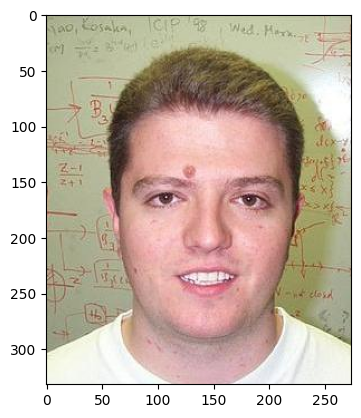

1000
(<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=300x143 at 0x11A47C450>, 20)


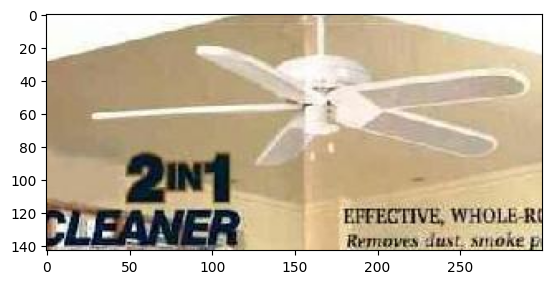

In [46]:
from torch.utils.data import Subset

N = 1000
# use the first N samples from the dataset
my_caltech_sub1 = Subset(
    dataset=my_caltech, 
    indices=np.arange(N)
)

# the subset behaves like an actual dataset
print(len(my_caltech_sub1))
print(my_caltech_sub1[500])

plt.figure()
plt.imshow(my_caltech_sub1[500][0])
plt.show()


# randomly sample from the dataset
# create a random set of int to be used as indices
idx = np.random.randint(low=0, high=len(my_caltech), size=N)
my_caltech_sub2 = Subset(
    dataset=my_caltech, 
    indices=idx
)

# the subset behaves like an actual dataset
print(len(my_caltech_sub2))
print(my_caltech_sub2[500])

plt.figure()
plt.imshow(my_caltech_sub2[500][0])
plt.show()
